In [37]:
import tensorflow as tf
import keras

In [38]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [39]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [40]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [41]:
y_train = (x_train > 0).astype("float32")
y_test = (x_test > 0).astype("float32")

In [42]:
x_train = x_train[...,tf.newaxis]
x_test = x_test[...,tf.newaxis]

y_train = y_train[...,tf.newaxis]
y_test = y_test[...,tf.newaxis]

In [43]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(28, 28, 1))

# Encoder
c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(c1)
p1 = layers.MaxPooling2D()(c1)

c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(p1)
c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(c2)
p2 = layers.MaxPooling2D()(c2)

# Bottleneck
c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(p2)
c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(c3)

# Decoder
u1 = layers.UpSampling2D()(c3)
u1 = layers.Concatenate()([u1, c2])
c4 = layers.Conv2D(64, 3, activation="relu", padding="same")(u1)
c4 = layers.Conv2D(64, 3, activation="relu", padding="same")(c4)

u2 = layers.UpSampling2D()(c4)
u2 = layers.Concatenate()([u2, c1])
c5 = layers.Conv2D(32, 3, activation="relu", padding="same")(u2)
c5 = layers.Conv2D(32, 3, activation="relu", padding="same")(c5)

# Output
outputs = layers.Conv2D(1, 1, activation="sigmoid")(c5)

In [44]:
unet = models.Model(inputs, outputs)

In [45]:
unet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_33[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_35[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 7, 7, 64)  │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 7, 7, 128) │    147,584 │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 14, 14,    │          0 │ conv2d_38[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 14, 14,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 192)              │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 14, 14,    │    110,656 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_39[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 28, 28,    │          0 │ conv2d_40[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 28, 28,    │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 96)               │            │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 28, 28,    │     27,680 │ concatenate_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_41[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 470,977 (1.80 MB)

 Trainable params: 470,977 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
unet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
x_train.shape, y_train.shape

((60000, 28, 28, 1), (60000, 28, 28, 1))

In [48]:
unet.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 786s 1s/step - accuracy: 0.9727 - loss: 0.0687 - val_accuracy: 0.9938 - val_loss: 0.0193
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 780s 1s/step - accuracy: 0.9972 - loss: 0.0092 - val_accuracy: 0.9992 - val_loss: 0.0037
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 736s 982ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 779s 1s/step - accuracy: 0.9998 - loss: 7.7016e-04 - val_accuracy: 0.9999 - val_loss: 3.6451e-04
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 778s 1s/step - accuracy: 0.9999 - loss: 2.6761e-04 - val_accuracy: 1.0000 - val_loss: 1.7143e-04


In [50]:
prediction = unet.predict(x_test[:1])

print(prediction.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
(1, 28, 28, 1)


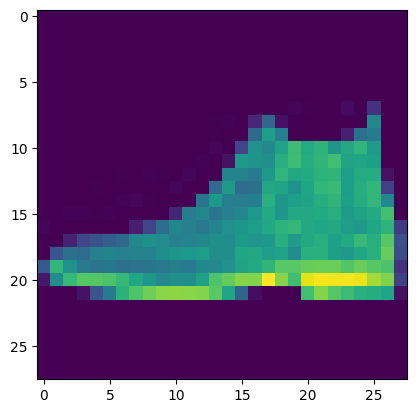

In [63]:
# test image
plt.imshow(x_test[0])

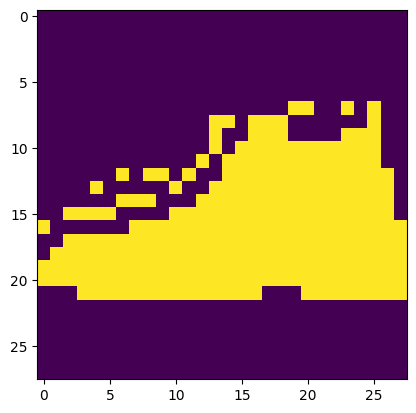

In [69]:
# predicted segmentation
import numpy as np
plt.imshow(np.squeeze(prediction))

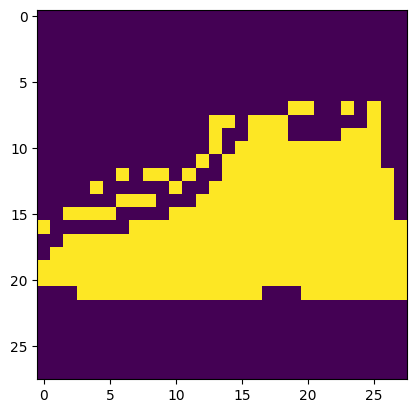

In [70]:
# actual segmentation
plt.imshow(y_test[0])

In [71]:
# SegNet
inputs = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)

# Bottleneck
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

# Decoder
x = layers.UpSampling2D()(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

x = layers.UpSampling2D()(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

# Output mask
outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

segnet = models.Model(inputs, outputs)

segnet.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 28, 28, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,313 (1.06 MB)

 Trainable params: 277,313 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
segnet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
segnet.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 568s 753ms/step - accuracy: 0.9482 - loss: 0.1257 - val_accuracy: 0.9694 - val_loss: 0.0746
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 621s 752ms/step - accuracy: 0.9733 - loss: 0.0644 - val_accuracy: 0.9774 - val_loss: 0.0547
Epoch 3/5
  2/750 ━━━━━━━━━━━━━━━━━━━━ 7:43 619ms/step - accuracy: 0.9759 - loss: 0.0590 

In [ ]:
loss, accuracy = segnet.evaluate(x_test, y_test)

print("SegNet Accuracy:", accuracy)

In [ ]:
prediction = segnet.predict(x_test[:1])

print(prediction.shape)